In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import math

class Transpose(nn.Module):
    def __init__(self, dim0, dim1):
        super().__init__()
        self.dim0 = dim0
        self.dim1 = dim1

    def forward(self, x):
        return x.transpose(self.dim0, self.dim1)

class PositionalEncoding2D(nn.Module):
    def __init__(self, num_patches, dim):
        super().__init__()
        self.register_buffer('pos_embed', self.build_sincos_encoding(num_patches, dim), persistent=False)

    def build_sincos_encoding(self, num_patches, dim):
        pe = torch.zeros(num_patches, dim)
        position = torch.arange(0, num_patches, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim, 2).float() * (-math.log(10000.0) / dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)  # [1, num_patches, dim]

    def forward(self, x):
        return x + self.pos_embed[:, :x.size(1), :]

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, out_channels)
        )
        self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)

class CondEncoder(nn.Module):
    def __init__(self, in_channels=4, out_channels=736, num_tokens=64):
        super().__init__()
        self.encoder = nn.Sequential(
            ResidualBlock(in_channels, 64), # [B, 64, 64, 64]
            nn.AvgPool2d(2), # [B, 64, 32, 32]
            ResidualBlock(64, 128),
            nn.AvgPool2d(2), # [B, 128, 16, 16]
            ResidualBlock(128, 256),
            nn.AvgPool2d(2), # [B, 256, 8, 8]
            nn.Conv2d(256, out_channels, kernel_size=1) # [B, 736, 8, 8]
        )
        self.proj = nn.Sequential(
            nn.Flatten(2),  # [B, 736, 64]
            Transpose(-1, -2),   # [B, 64, 736]
        )
        self.pos_embed = PositionalEncoding2D(num_patches=num_tokens, dim=out_channels)
        self.norm = nn.LayerNorm(out_channels)

    def forward(self, x):
        feat = self.encoder(x)          # [B, 736, 8, 8]
        tokens = self.proj(feat)        # [B, 64, 736]
        tokens = self.pos_embed(tokens) # [B, 64, 736]
        tokens = self.norm(tokens)
        return tokens


In [3]:
import torch.nn.functional as F
import math

def gaussian_blur_rgb(img, k=41, sigma=10.0):
    """Separable Gaussian blur on RGB. img in [-1,1], (B,3,H,W)."""
    pad = k // 2
    x = torch.arange(k, device=img.device, dtype=img.dtype) - pad
    g = torch.exp(-(x**2) / (2 * sigma**2)); g = g / g.sum()
    gx = g.view(1,1,1,k).repeat(3,1,1,1)
    gy = g.view(1,1,k,1).repeat(3,1,1,1)
    img = F.pad(img, (pad,pad,0,0), mode='reflect'); img = F.conv2d(img, gx, groups=3)
    img = F.pad(img, (0,0,pad,pad), mode='reflect'); img = F.conv2d(img, gy, groups=3)
    return img

def build_color_map(image_tensor, fg_mask=None):
    """
    Low-frequency color map from image in [-1,1], (B,3,512,512).
    If fg_mask (B,1,H,W) provided, keep original image on background.
    """
    cmap = gaussian_blur_rgb(image_tensor, k=41, sigma=10.0)
    if fg_mask is not None:
        cmap = fg_mask * cmap + (1.0 - fg_mask) * image_tensor
    return cmap

def cosine_taper(step_idx, total_steps, start_frac=0.0, end_frac=0.35):
    """Weight in [0,1] that decays 1→0 over [start_frac,end_frac] of steps."""
    s = int(total_steps * start_frac); e = max(s+1, int(total_steps * end_frac))
    if step_idx < s or step_idx > e: return 0.0
    x = (step_idx - s) / (e - s)
    return 0.5 * (1.0 + math.cos(math.pi * x))


In [6]:
import torch
import torch.nn as nn
from diffusers import DDPMScheduler, UNet2DConditionModel, AutoencoderKL
from accelerate import Accelerator
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

class OutpaintGenerator:
    def __init__(self, pretrained_path="runwayml/stable-diffusion-v1-5"):
        self.accelerator = Accelerator(mixed_precision='fp16')
        self.vae = AutoencoderKL.from_pretrained(pretrained_path, subfolder="vae")
        self.unet = UNet2DConditionModel.from_pretrained(pretrained_path, subfolder="unet")
        self.scheduler = DDPMScheduler.from_pretrained(
            "runwayml/stable-diffusion-v1-5",
            subfolder="scheduler"
        )

        # Coordinate Encoder
        self.coord_encoder = nn.Sequential(nn.Linear(4, 32), nn.GELU())

        # Conditional Projection Layer

        self.cond_proj = CondEncoder()

        # Prepare components for mixed precision
        components = [self.vae, self.unet, self.coord_encoder, self.cond_proj]
        self.vae, self.unet, self.coord_encoder, self.cond_proj = \
            self.accelerator.prepare(*components)

        # Optimizer
        self.optimizer = torch.optim.AdamW(
            list(self.unet.parameters()) +
            list(self.coord_encoder.parameters()) +
            list(self.cond_proj.parameters()),
            lr = 1e-5)

        self.optimizer = self.accelerator.prepare(self.optimizer)

        # Noise Scheduler
        self.noise_scheduler = DDPMScheduler.from_pretrained(
            pretrained_path, subfolder="scheduler")
        self.accelerator.register_for_checkpointing(self.unet, self.coord_encoder, self.cond_proj, self.optimizer)
        # Prepare for inference
        self.vae.requires_grad_(False)
        self.unet.requires_grad_(False)
        self.coord_encoder.requires_grad_(False)
        self.cond_proj.requires_grad_(False)

        # Define transformation
        self.transform = transforms.Compose([
            #transforms.Resize((512, 512)),
            transforms.ToTensor(),
            transforms.Normalize([0.5] * 3, [0.5] * 3)
        ])

    def _create_latent_mask(self, bbox, latent_shape):
        b, _, lh, lw = latent_shape
        masks = []
        for coords in bbox:
            # Convert coordinates to latent space
            x1 = coords[0] * lw
            y1 = coords[1] * lh
            x2 = coords[2] * lw
            y2 = coords[3] * lh

            # Create basic mask
            xx, yy = torch.meshgrid(
                torch.arange(lw, device=self.accelerator.device),
                torch.arange(lh, device=self.accelerator.device))
            mask = ((xx >= x1) & (xx <= x2) & (yy >= y1) & (yy <= y2)).float()
            masks.append(mask)
        return torch.stack(masks).unsqueeze(1)



    def generate_image(self, masked_img, bbox, steps, j):
      # ---- Encode image to latents ----
      masked_latents = self.vae.encode(masked_img).latent_dist.sample()
      masked_latents = masked_latents * self.vae.config.scaling_factor  # [B,4,64,64]

      # ---- Base tokens (existing) ----
      coord_features = self.coord_encoder(bbox)                         # [B,32]
      base_tokens = self.cond_proj(masked_latents)                      # [B,64,736]
      coord_tokens = coord_features.unsqueeze(1).expand(-1, 64, -1)     # [B,64,32]
      base_ctx = torch.cat([base_tokens, coord_tokens], dim=-1)         # [B,64,768]

      # ---- Latent & image masks ----
      latent_masks = self._create_latent_mask(bbox, masked_latents.shape)              # [B,1,64,64]
      img_mask = F.interpolate(latent_masks, size=masked_img.shape[-2:], mode="nearest")

      # ---- Build low-frequency color map & encode with CondEncoder (RGB) ----
      # masked_img is already in [-1,1] due to your Normalize([0.5],[0.5])
      color_map = build_color_map(masked_img, fg_mask=img_mask)         # [B,3,512,512] in [-1,1]
      with torch.no_grad():
          color_tokens = self.color_encoder(color_map)                  # [B,64,736]
          color_ctx    = self.color_proj(color_tokens)                  # [B,64,768]

      # ---- Noise init (masked region only) ----
      noise = torch.randn_like(masked_latents)
      noisy_latents = self.noise_scheduler.add_noise(
          masked_latents * latent_masks, noise * latent_masks, torch.tensor(steps)
      )
      latent_input = masked_latents * (1 - latent_masks) + noisy_latents * latent_masks

      # ---- Denoise with early color guidance ----
      self.scheduler.set_timesteps(steps)
      for i, t in enumerate(self.scheduler.timesteps, start=1):
          # keep unmasked region clamped
          latent_input = latent_input * latent_masks + masked_latents * (1 - latent_masks)

          w_col = cosine_taper(i, steps, self.color_t_start, self.color_t_end) * self.color_token_scale
          if w_col > 0:
              cond = torch.cat([base_ctx, w_col * color_ctx], dim=1)    # [B,128,768]
          else:
              cond = base_ctx                                          # [B,64,768]

          with torch.no_grad():
              noise_pred = self.unet(latent_input, t, encoder_hidden_states=cond).sample
          latent_input = self.scheduler.step(noise_pred, t, latent_input).prev_sample

      # ---- Decode & save ----
      with torch.no_grad():
          blended_latent = masked_latents * (1 - latent_masks) + latent_input * latent_masks
          path = f"{j}_latent.pt"
          torch.save(
              {
                  "blended_latent": blended_latent.float().cpu(),
                  "vae_scaling_factor": float(self.vae.config.scaling_factor),
                  "shape": tuple(blended_latent.shape),
                  "notes": "Decode with vae.decode(latent/scaling_factor)."
              },
              path
          )
          generated = self.vae.decode(blended_latent / self.vae.config.scaling_factor).sample
          generated = generated[0].permute(1, 2, 0).cpu().numpy()
          generated = (generated * 0.5 + 0.5).clip(0, 1)
          masked_img1 = masked_img[0].cpu().permute(1, 2, 0).numpy()
          masked_img1 = (masked_img1 * 0.5 + 0.5).clip(0, 1)
          generated_u8 = (generated * 255).astype(np.uint8)
          Image.fromarray(generated_u8).save(f"{j}.png")

          plt.figure(figsize=(12, 6))
          plt.subplot(121); plt.imshow(masked_img1); plt.title("Masked Input"); plt.axis('off')
          plt.subplot(122); plt.imshow(generated_u8); plt.title("Generated Output"); plt.axis('off')
          plt.show()



def preview_mask_over_image(img_tensor_01, x1, y1, x2, y2, title="Mask preview"):
    """
    img_tensor_01: [1,3,H,W] on CPU, in [0,1]
    draws a semi-transparent red rectangle over the masked region
    """
    import matplotlib.patches as patches
    img = img_tensor_01[0].permute(1,2,0).numpy()
    H, W = img.shape[:2]

    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(img)
    rect = patches.Rectangle((x1, y1), (x2-x1), (y2-y1), linewidth=2, edgecolor='r', facecolor='r', alpha=0.25)
    ax.add_patch(rect)
    ax.set_title(title)
    ax.axis("off")
    plt.show()


In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, glob  # <-- added
generator = OutpaintGenerator()
generator.accelerator.load_state('/content/drive/MyDrive/checkpoint_LR')


Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

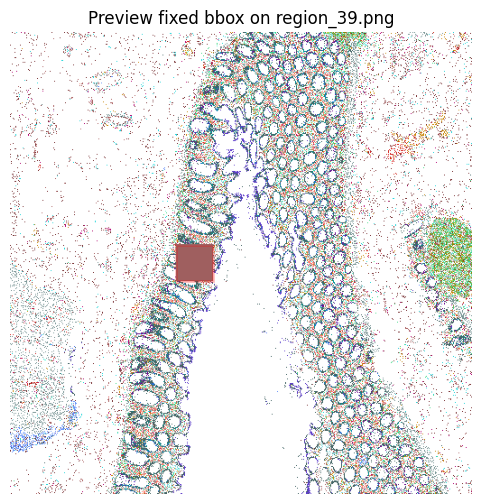

[1/1] Generating: /content/drive/MyDrive/inpaint_bootstrap/region_39/region_39_samebox_1.png
tensor(0.0005, device='cuda:0')


/usr/local/lib/python3.12/dist-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


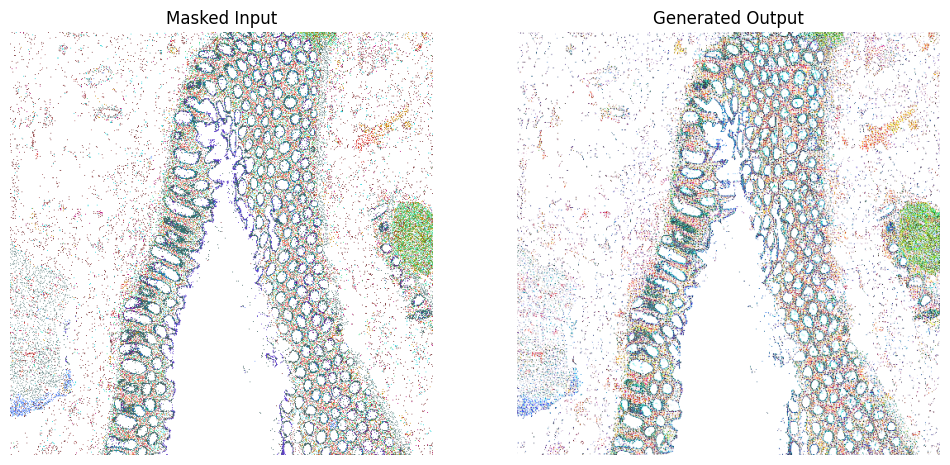


✅ Done. Saved to: /content/drive/MyDrive/inpaint_bootstrap/region_39/


In [7]:
import os
import torch
from PIL import Image

# ===== paths & run settings =====
IMG_PATH  = "/content/drive/MyDrive/202509CURRENT_Diff_VAL_set/region_39.png"  # your image
SAVE_DIR  = "/content/drive/MyDrive/inpaint_bootstrap/region_39/"
NUM_RUNS  = 1
STEPS     = 150  # your previous setting

os.makedirs(SAVE_DIR, exist_ok=True)

# ===== fixed bbox (normalized [x1,y1,x2,y2]) =====
# pick your exact region here; example: a small 8% x 8% box near the center
bbox_norm_fixed = [0.36, 0.46, 0.44, 0.54]

# ===== load & prep image once =====
img = Image.open(IMG_PATH).convert("RGB")
masked_img = generator.transform(img).unsqueeze(0).to(generator.accelerator.device)  # [1,3,H,W]
B, C, H, W = masked_img.shape

# ===== make a pixel-space preview of the masked input (optional) =====
x1 = int(bbox_norm_fixed[0] * W)
y1 = int(bbox_norm_fixed[1] * H)
x2 = int(bbox_norm_fixed[2] * W)
y2 = int(bbox_norm_fixed[3] * H)

mask = torch.ones_like(masked_img)
mask[:, :, y1:y2, x1:x2] = 0
masked_img_preview = (masked_img * mask)
preview_img = ((masked_img_preview.float().cpu()[0] * 0.5 + 0.5).unsqueeze(0)).clamp(0, 1)
preview_mask_over_image(preview_img, x1, y1, x2, y2,
                        title=f"Preview fixed bbox on {os.path.basename(IMG_PATH)}")

# ===== run 20 times with the exact same region =====
bbox_tensor = torch.tensor([bbox_norm_fixed], dtype=torch.float16, device=generator.accelerator.device)

# ensure modules are on GPU (as in your code)
generator.unet.to("cuda:0")
generator.coord_encoder.to("cuda:0")
generator.cond_proj.to("cuda:0")

base = os.path.splitext(os.path.basename(IMG_PATH))[0]
for i in range(1, NUM_RUNS + 1):
    run_name = f"{base}_samebox_{i}"
    j_path   = os.path.join(SAVE_DIR, run_name)   # generate_image adds .png / _latent.pt
    print(f"[{i}/{NUM_RUNS}] Generating: {j_path}.png")
    # pass the ORIGINAL image; masking is done in latent space inside generate_image
    generator.generate_image(masked_img, bbox_tensor, STEPS, j=j_path)

print(f"\n✅ Done. Saved to: {SAVE_DIR}")
